# RAFT (Retrieval Augmented Fine-Tuning) with Unsloth & LoRA

Notebook ini dibuat untuk melakukan fine-tuning model LLM menggunakan dataset RAFT (`raft_dataset_finalv1.jsonl` dan `raft_dataset_multi_oracle.jsonl`) dengan teknik LoRA (Low-Rank Adaptation) dan *library* Unsloth agar proses *training* jauh lebih cepat dan hemat memori.

### Mengapa RAFT Tahan Terhadap Distraktor?
Dalam paper jurnal **"RAFT: Adapting Language Model to Domain Specific RAG"** (Zhang et al., 2024), model tidak hanya dilatih untuk menjawab berdasarkan konteks yang relevan (Oracle), tetapi juga **sengaja diberikan dokumen distraktor (irrelevant/noise)**.
- Model dipaksa belajar melalui *Chain-of-Thought* (CoT) (dalam dataset Anda disebut `thought_process`) untuk memilah mana dokumen yang benar-benar relevan dan mana yang tidak.
- Untuk beberapa *training sample*, model bahkan dilatih untuk menolak menjawab jika tidak ada dokumen *oracle* sama sekali (100% distraktor).
- Hasilnya, model fine-tuning ini menjadi sangat robust (tahan uji) ketika di-deploy dalam sistem RAG nyata yang seringkali hasil *retrieval*-nya (dari Vector Database) kurang akurat atau mengandung banyak *noise*.

Referensi Jurnal:
- Zhang, D., et al. (2024). *RAFT: Adapting Language Model to Domain Specific RAG*. arXiv preprint arXiv:2403.10131. URL: https://arxiv.org/abs/2403.10131

In [7]:
# %%capture
# !pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
# !pip install --no-deps xformers trl peft accelerate bitsandbytes datasets

### STEP 1: Cek Lingkungan (GPU & Library)

In [1]:
import torch
import transformers
import trl

print("=" * 60)
print("CEK LINGKUNGAN")
print("=" * 60)
print(f"PyTorch version   : {torch.__version__}")
print(f"Transformers ver  : {transformers.__version__}")
print(f"TRL version       : {trl.__version__}")
print(f"CUDA available    : {torch.cuda.is_available()}")
print(f"GPU count         : {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}            : {torch.cuda.get_device_name(i)}")
        props = torch.cuda.get_device_properties(i)
        print(f"  Total memory    : {props.total_memory / 1024**3:.2f} GB")
        print(f"  Compute cap     : {props.major}.{props.minor}")
print("=" * 60)

assert torch.cuda.is_available(), "CUDA tidak tersedia! Pastikan GPU terdeteksi."

/workspace/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CEK LINGKUNGAN
PyTorch version   : 2.11.0+cu128
Transformers ver  : 5.5.0
TRL version       : 0.24.0
CUDA available    : True
GPU count         : 1
GPU 0            : NVIDIA B200
  Total memory    : 178.36 GB
  Compute cap     : 10.0


## 1. Load Model dengan Unsloth & Konfigurasi LoRA
Kita akan menggunakan model `Llama-3-8B-Instruct` sebagai *base model*. Unsloth menyediakan model dalam format 4-bit secara bawaan untuk penghematan memori.

In [2]:
from unsloth import FastLanguageModel
import torch

MODEL_NAME = "../model/Meta-Llama-3.1-8B-Instruct"
MAX_SEQ_LENGTH = 4096
DTYPE = None
LOAD_IN_4BIT = False

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=LOAD_IN_4BIT,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/workspace/.venv/lib/python3.10/site-packages/unsloth/__init__.py:153: UserWarning: WARNING: Unsloth should be imported before [trl, transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA B200. Num GPUs = 1. Max memory: 178.361 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 10.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 291/291 [00:02<00:00, 143.59it/s]
Unsloth: Will load ../model/Meta-Llama-3.1-8B-Instruct as a legacy tokenizer.


../model/Meta-Llama-3.1-8B-Instruct does not have a padding token! Will use pad_token = <|finetune_right_pad_id|>.


## LORA

In [3]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

print("Model + LoRA berhasil dimuat.")

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.6.9 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Model + LoRA berhasil dimuat.


## 2. Persiapan & Formatting Dataset RAFT
Di sini kita akan memproses format dataset `raft_dataset_finalv1.jsonl` dan menyatukannya dalam struktur *prompt* instruksi. Model akan diajarkan untuk merangkai `<thought>` (Chain of Thought) terlebih dahulu untuk memilah dokumen distraktor sebelum memberikan jawaban akhir.

In [4]:
from datasets import load_dataset, concatenate_datasets

dataset_path_1 = "../data/dataset/raft_dataset_finalv3.jsonl"

try:
    ds1 = load_dataset("json", data_files=dataset_path_1, split="train")

    cols_to_remove = ["metadata_extra", "validation"]
    ds1 = ds1.remove_columns([c for c in cols_to_remove if c in ds1.column_names])

    dataset = concatenate_datasets([ds1])
    print(f"Berhasil dimuat! Total data: {len(dataset)} baris.")

except Exception as e:
    print(f"Error: {e}")

# ==========================================================
# PROMPT BARU: fokus ke pemilihan konteks + jawaban akhir
# ==========================================================

raft_prompt = """<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Anda adalah asisten AI ahli dalam menjawab pertanyaan berdasarkan dokumen hukum dan peraturan desa.

Tugas Anda:
1. Periksa semua dokumen referensi yang diberikan.
2. Pilih hanya dokumen yang benar-benar menjawab pertanyaan.
3. Abaikan dokumen yang tidak relevan, salah pasal/ayat, atau hanya mirip topiknya.
4. Jika tidak ada dokumen yang valid, katakan bahwa informasi tidak ditemukan pada dokumen yang diberikan.
5. Jawaban akhir hanya boleh berdasarkan dokumen yang dipilih.

Format jawaban HARUS seperti ini:
KONTEKS_DIPILIH: [id dokumen]
KONTEKS_DITOLAK: [id dokumen]
JAWABAN:
<jawaban akhir>

<|eot_id|><|start_header_id|>user<|end_header_id|>

Pertanyaan: {instruction}

Dokumen Referensi:
{documents}

<|eot_id|><|start_header_id|>assistant<|end_header_id|>
KONTEKS_DIPILIH: {selected_doc_ids}

KONTEKS_DITOLAK: {rejected_doc_ids}

JAWABAN:
{completion}"""

EOS_TOKEN = tokenizer.eos_token


def extract_selected_and_rejected_ids(thought_process, total_docs):
    """
    Mengubah thought_process.document_analysis menjadi:
    - selected_doc_ids
    - rejected_doc_ids

    Aturan heuristik awal:
    selected jika analysis mengandung sinyal bahwa dokumen:
    - langsung menjawab pertanyaan
    - memberikan informasi yang dibutuhkan
    - mencakup pasal/ayat yang diminta
    """
    selected = []

    doc_analysis = thought_process.get("document_analysis", []) if thought_process else []

    positive_cues = [
        "langsung menjawab pertanyaan",
        "memberikan informasi yang dibutuhkan",
        "mencakup pasal",
        "mencakup pasal 12 ayat",
        "secara jelas",
        "ini merupakan informasi penting yang langsung menjawab pertanyaan",
        "memberikan informasi lengkap",
    ]

    negative_cues = [
        "tidak relevan",
        "tidak memberikan informasi yang dibutuhkan",
        "tidak berkaitan",
        "ayat (3)",
        "berbeda",
        "tidak mencakup",
    ]

    for item in doc_analysis:
        doc_id = item.get("document")
        analysis = item.get("analysis", "").lower()

        # kalau ada cue negatif yang kuat, reject
        if any(cue in analysis for cue in negative_cues):
            continue

        # kalau ada cue positif, select
        if any(cue in analysis for cue in positive_cues):
            selected.append(doc_id)

    # fallback:
    # kalau heuristik gagal dan tidak ada selected,
    # pilih dokumen pertama yang TIDAK mengandung "tidak relevan"
    if not selected:
        for item in doc_analysis:
            doc_id = item.get("document")
            analysis = item.get("analysis", "").lower()
            if "tidak relevan" not in analysis and "tidak memberikan informasi" not in analysis:
                selected.append(doc_id)
                break

    rejected = [i for i in range(1, total_docs + 1) if i not in selected]
    return selected, rejected


def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    docs_lists = examples["documents"]
    thought_processes = examples["thought_process"]
    completions = examples["completion"]

    texts = []

    for instruction, docs, thought, completion in zip(
        instructions, docs_lists, thought_processes, completions
    ):
        # Format dokumen
        formatted_docs = ""
        for idx, doc in enumerate(docs):
            formatted_docs += f"[{idx+1}] {doc}\n\n"

        # Ekstrak selected/rejected dari thought_process
        selected_ids, rejected_ids = extract_selected_and_rejected_ids(
            thought_process=thought,
            total_docs=len(docs)
        )

        text = raft_prompt.format(
            instruction=instruction,
            documents=formatted_docs.strip(),
            selected_doc_ids=selected_ids,
            rejected_doc_ids=rejected_ids,
            completion=completion
        ) + EOS_TOKEN

        texts.append(text)

    return {"text": texts}


if 'dataset' in locals():
    dataset = dataset.map(
        formatting_prompts_func,
        batched=True,
        remove_columns=dataset.column_names
    )

    print("\n--- Contoh Hasil Format Prompt Baris Pertama ---\n")
    print(dataset[0]["text"])

Generating train split: 405 examples [00:00, 55625.55 examples/s]


Berhasil dimuat! Total data: 405 baris.


Map: 100%|██████████| 405/405 [00:00<00:00, 19226.43 examples/s]


--- Contoh Hasil Format Prompt Baris Pertama ---

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Anda adalah asisten AI ahli dalam menjawab pertanyaan berdasarkan dokumen hukum dan peraturan desa.

Tugas Anda:
1. Periksa semua dokumen referensi yang diberikan.
2. Pilih hanya dokumen yang benar-benar menjawab pertanyaan.
3. Abaikan dokumen yang tidak relevan, salah pasal/ayat, atau hanya mirip topiknya.
4. Jika tidak ada dokumen yang valid, katakan bahwa informasi tidak ditemukan pada dokumen yang diberikan.
5. Jawaban akhir hanya boleh berdasarkan dokumen yang dipilih.

Format jawaban HARUS seperti ini:
KONTEKS_DIPILIH: [id dokumen]
KONTEKS_DITOLAK: [id dokumen]
JAWABAN:
<jawaban akhir>

<|eot_id|><|start_header_id|>user<|end_header_id|>

Pertanyaan: Apa sih arti pemerintahan desa itu ?

Dokumen Referensi:
[1] [dokumen: Peraturan Desa Biru No. 10 Tahun 2016 - Pemberdayaan Perempuan Dan Perlindungan Anak] [desa: biru] [kabupaten: bandung] [nomor: 10/2016]

pasal 1

2. pem

## 3. Training Menggunakan SFTTrainer dari TRL

In [5]:
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported

from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported

sft_config = SFTConfig(
    dataset_text_field="text",
    max_seq_length=4096,
    dataset_num_proc=2,
    packing=False,

    per_device_train_batch_size=4,
    gradient_accumulation_steps=8,
    num_train_epochs=3,

    learning_rate=1e-4,
    warmup_ratio=0.05,
    weight_decay=0.01,

    fp16=not is_bfloat16_supported(),
    bf16=is_bfloat16_supported(),

    logging_steps=10,
    optim="adamw_8bit",
    lr_scheduler_type="linear",
    seed=3407,

    output_dir="../model/outputs_lora",
    logging_dir="../model/outputs_lora/tensorboard_logs",
    report_to="none",

    save_strategy="epoch",
    save_total_limit=3,
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,
    args=sft_config,
)

print("\n>>> Memulai training...")
trainer_stats = trainer.train() 


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
Unsloth: Tokenizing ["text"] (num_proc=2): 100%|██████████| 405/405 [00:01<00:00, 391.10 examples/s]
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.

>>> Memulai training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 405 | Num Epochs = 3 | Total steps = 39
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 8 x 1) = 32
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
10,0.943876
20,0.501407
30,0.407486


Unsloth: Restored added_tokens_decoder metadata in ../model/outputs_lora/checkpoint-13/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ../model/outputs_lora/checkpoint-26/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ../model/outputs_lora/checkpoint-39/tokenizer_config.json.


## Train loss + Validation loss

,loss,grad_norm,learning_rate,epoch,step,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
41,0.280240,0.139944,0.000069,3.24,42,NaN,NaN,NaN,NaN,NaN
42,0.279829,0.158780,0.000065,3.32,43,NaN,NaN,NaN,NaN,NaN
43,0.255510,0.154719,0.000062,3.40,44,NaN,NaN,NaN,NaN,NaN
44,0.290705,0.142219,0.000058,3.48,45,NaN,NaN,NaN,NaN,NaN
45,0.278609,0.156615,0.000055,3.56,46,NaN,NaN,NaN,NaN,NaN
46,0.258306,0.159737,0.000051,3.64,47,NaN,NaN,NaN,NaN,NaN
47,0.248859,0.157817,0.000047,3.72,48,NaN,NaN,NaN,NaN,NaN
48,0.251108,0.171587,0.000044,3.80,49,NaN,NaN,NaN,NaN,NaN
49,0.248100,0.160688,0.000040,3.88,50,NaN,NaN,NaN,NaN,NaN
50,0.247655,0.162682,0.000036,3.96,51,NaN,NaN,NaN,NaN,NaN


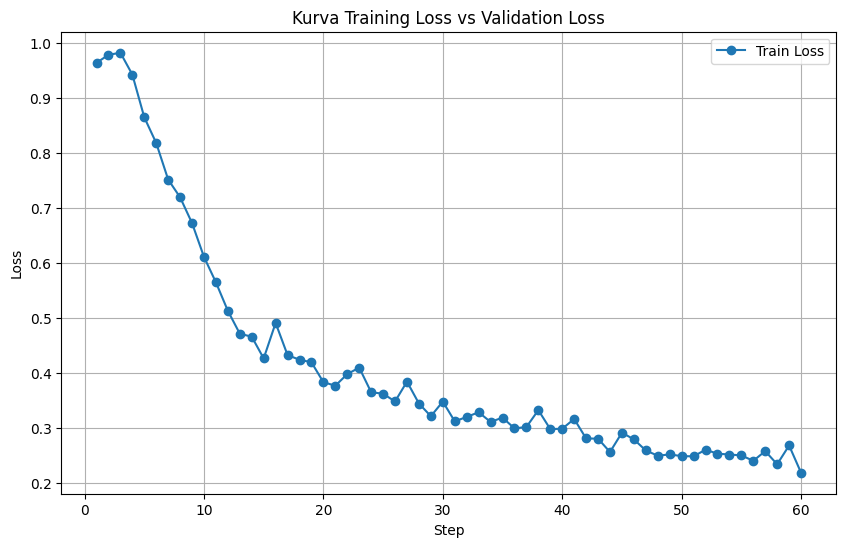

Train loss terakhir:


,step,loss
55,56,0.239511
56,57,0.257139
57,58,0.233248
58,59,0.267423
59,60,0.217845


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# AMBIL LOG HISTORY
# =========================
log_history = trainer.state.log_history
log_df = pd.DataFrame(log_history)

display(log_df.tail(20))

# Train loss
train_logs = log_df[log_df["loss"].notna()].copy() if "loss" in log_df.columns else pd.DataFrame()

# Eval loss
eval_logs = log_df[log_df["eval_loss"].notna()].copy() if "eval_loss" in log_df.columns else pd.DataFrame()

plt.figure(figsize=(10, 6))

if not train_logs.empty:
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="Train Loss")

if not eval_logs.empty:
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="Validation Loss")

plt.title("Kurva Training Loss vs Validation Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

if not train_logs.empty:
    print("Train loss terakhir:")
    display(train_logs[["step", "loss"]].tail())

if not eval_logs.empty:
    print("Validation loss terakhir:")
    display(eval_logs[["step", "eval_loss"]].tail())

## Ringkasan metrik training

In [ ]:
metrics = trainer_stats.metrics

print("=" * 60)
print("RINGKASAN TRAINING")
print("=" * 60)
for k, v in metrics.items():
    print(f"{k}: {v}")

print("=" * 60)
print(f"Best checkpoint : {trainer.state.best_model_checkpoint}")
print(f"Best eval loss  : {trainer.state.best_metric}")
print("=" * 60)

RINGKASAN TRAINING
train_runtime: 1350.181
train_samples_per_second: 1.422
train_steps_per_second: 0.044
total_flos: 1.2897292026352435e+17
train_loss: 0.4139738770822684
epoch: 4.64
Best checkpoint : None
Best eval loss  : None


## Evaluasi generatif pada validation set

In [ ]:
from unsloth import FastLanguageModel
import pandas as pd
from tqdm import tqdm
import torch
import re
import ast
import json


FastLanguageModel.for_inference(model)

def build_inference_prompt(instruction, documents):
    formatted_docs = format_documents(documents)

    prompt = f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Anda adalah asisten AI ahli dalam menjawab pertanyaan berdasarkan dokumen hukum dan peraturan desa.
Diberikan sejumlah dokumen referensi, analisislah dokumen tersebut untuk mencari jawaban yang tepat.
Tuliskan proses berpikir Anda di dalam tag <thought>...</thought> dengan menjelaskan dokumen mana yang relevan dan tidak relevan (distraktor).
Setelah itu, berikan jawaban akhir Anda berdasarkan hasil analisis tersebut.<|eot_id|><|start_header_id|>user<|end_header_id|>

Pertanyaan: {instruction}

Dokumen Referensi:
{formatted_docs}
<|eot_id|><|start_header_id|>assistant<|end_header_id|>

<thought>
"""
    return prompt



def clean_generated_answer(text):
    if text is None:
        return ""

    text = str(text).strip()

    # hapus special token dasar
    special_tokens = [
        "<|eot_id|>",
        "<|start_header_id|>",
        "<|end_header_id|>",
        "<|begin_of_text|>",
    ]
    for tok in special_tokens:
        text = text.replace(tok, "")

    text = text.strip()

    if "</thought>" in text:
        after_thought = text.split("</thought>", 1)[-1].strip()
    else:
        after_thought = text

    candidate = after_thought.strip()

    try:
        obj = ast.literal_eval(candidate)
        if isinstance(obj, dict):
            for key in ["final_answer", "answer", "response"]:
                if key in obj and obj[key]:
                    return str(obj[key]).strip()
    except Exception:
        pass

    try:
        obj = json.loads(candidate)
        if isinstance(obj, dict):
            for key in ["final_answer", "answer", "response"]:
                if key in obj and obj[key]:
                    return str(obj[key]).strip()
    except Exception:
        pass

    m = re.search(r'"?final_answer"?\s*:\s*"([^"]+)"', candidate, flags=re.DOTALL | re.IGNORECASE)
    if m:
        return m.group(1).strip()


    return candidate.strip()

def generate_answer_only(model, tokenizer, instruction, documents, max_new_tokens=256):
    prompt = build_inference_prompt(instruction, documents)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
    ).to(model.device)

    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=True,
            temperature=0.0,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Ambil hanya token hasil generasi model
    generated_ids = outputs[0][input_len:]
    generated_text = tokenizer.decode(generated_ids, skip_special_tokens=False)

    final_answer = clean_generated_answer(generated_text)

    return {
        "prompt": prompt,
        "raw_generation": generated_text,   # output mentah model
        "final_answer": final_answer,       # jawaban akhir yang sudah dibersihkan
    }

In [ ]:
N_EVAL_SAMPLES = min(20, len(val_raw))
rows = []

for i in tqdm(range(N_EVAL_SAMPLES), desc="Evaluating validation samples"):
    row = val_raw[i]

    instruction = row["instruction"]
    documents = row["documents"]
    reference = row["completion"]

    result = generate_answer_only(
        model=model,
        tokenizer=tokenizer,
        instruction=instruction,
        documents=documents,
        max_new_tokens=256
    )

    rows.append({
        "idx": i,
        "instruction": instruction,
        "reference": reference,
        "prediction_raw": result["raw_generation"],
        "prediction_final": result["final_answer"],
    })

eval_df = pd.DataFrame(rows)

display(
    eval_df[["idx", "instruction", "reference", "prediction_final"]].head(10)
)

NameError: name 'val_raw' is not defined

## Skor sederhana berbasis exact match longgar

In [ ]:
import re

def normalize_text(s):
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s


def token_overlap_score(pred, ref):
    pred_tokens = set(normalize_text(pred).split())
    ref_tokens = set(normalize_text(ref).split())
    if len(ref_tokens) == 0:
        return 0.0
    return len(pred_tokens & ref_tokens) / len(ref_tokens)


eval_df["token_overlap"] = eval_df.apply(
    lambda x: token_overlap_score(x["prediction_final"], x["reference"]),
    axis=1
)

print("Avg token overlap:", eval_df["token_overlap"].mean())

display(
    eval_df[
        ["idx", "instruction", "reference", "prediction_final", "token_overlap"]
    ].head(10)
)

NameError: name 'eval_df' is not defined

## DEMO INFERENCE

In [ ]:
FastLanguageModel.for_inference(model)

test_instruction = "Siapa saja unsur masyarakat yang diundang dan harus hadir dalam Musyawarah Desa pemilihan kewenangan di Desa Cigentur?"
test_docs = [
    "unsur masyarakat  Musyawarah Desa pemilihan kewenangan di Desa cigentur dimaksud pada ayat (1) terdiri dari : a. perwakilan perangkat desa;\nb. anggota badan permusyawaratan desa (bpd);\nc. perwakilan kecamatan;\nd. perwakilan pengusaha lokal;\ne. ketua rukun warga (rw).",
"unsur masyarakat sebagaimana dimaksud pada ayat (1) terdiri dari : a. tokoh agama;\nb. tokoh masyarakat;\nc. tokoh pendidik;\nd. perwakilan kelompok tani;\ne. perwakilan kelompok perajin;\nf. perwakilan kelompok perempuan;\ng. perwakilan kelompok pemerhati dan perlindungan anak; dan\nh. perwakilan kelompok masyarakat miskin."
]

test_result = generate_answer_only(
    model=model,
    tokenizer=tokenizer,
    instruction=test_instruction,
    documents=test_docs,
    max_new_tokens=2000
)

print("=== RAW GENERATION ===")
print(test_result["raw_generation"])

print("\n=== FINAL ANSWER ===")
print(test_result["final_answer"])

NameError: name 'format_documents' is not defined

## SAVE MODEL

In [6]:
# =========================
# SAVE LoRA ADAPTER
# =========================
ADAPTER_DIR = "/workspace/model/lora_adapter_raft_v2"
MERGED_DIR  = "/workspace/model/model_merged_raft_v2"

model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print(f"LoRA adapter disimpan ke: {ADAPTER_DIR}")

# =========================
# SAVE MERGED MODEL
# =========================
model.save_pretrained_merged(
    MERGED_DIR,
    tokenizer,
    save_method="merged_16bit"
)

print(f"Merged model disimpan ke: {MERGED_DIR}")

Unsloth: Restored added_tokens_decoder metadata in /workspace/model/lora_adapter_raft_v2/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /workspace/model/model_merged_raft_v2/tokenizer_config.json.


LoRA adapter disimpan ke: /workspace/model/lora_adapter_raft_v2
Detected local model directory: /workspace/model/Meta-Llama-3.1-8B-Instruct
Found HuggingFace hub cache directory: /home/kel07/.cache/huggingface/hub


Unsloth: Preparing safetensor model files:  25%|██▌       | 1/4 [00:00<00:01,  2.02it/s]

Copied model-00004-of-00004.safetensors from local model directory


Unsloth: Preparing safetensor model files:  50%|█████     | 2/4 [00:02<00:02,  1.38s/it]

...

Copied model-00002-of-00004.safetensors from local model directory


Unsloth: Preparing safetensor model files: 100%|██████████| 4/4 [00:06<00:00,  1.64s/it]


Copied model-00001-of-00004.safetensors from local model directory


Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [00:30<00:00,  7.67s/it]


Unsloth: Merge process complete. Saved to `/workspace/model/model_merged_raft_v2`
Merged model disimpan ke: /workspace/model/model_merged_raft_v2


## load model

In [6]:
from unsloth import FastLanguageModel
import torch

MODEL_DIR = "/workspace/model/model_merged_raft_v4"
MAX_SEQ_LENGTH = 4096
DTYPE = None
LOAD_IN_4BIT = False

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_DIR,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=LOAD_IN_4BIT,
)

FastLanguageModel.for_inference(model)

print("Model inference berhasil dimuat.")

==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA B200. Num GPUs = 1. Max memory: 178.361 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 10.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 291/291 [00:02<00:00, 114.95it/s]
The tokenizer you are loading from '/workspace/model/model_merged_raft_v4' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
The tokenizer you are loading from '/workspace/model/model_merged_raft_v4' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Unsloth: Will load /workspace/model/model_merged_raft_v4 as a legacy tokenizer.


Model inference berhasil dimuat.


## Promt template

In [7]:
INFER_PROMPT = """<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Anda adalah asisten AI ahli dalam menjawab pertanyaan berdasarkan dokumen hukum dan peraturan desa.

Tugas Anda:
1. Periksa semua dokumen referensi yang diberikan.
2. Pilih hanya dokumen yang benar-benar menjawab pertanyaan.
3. Abaikan dokumen yang tidak relevan, salah pasal/ayat, atau hanya mirip topiknya.
4. Jika tidak ada dokumen yang valid, katakan bahwa informasi tidak ditemukan pada dokumen yang diberikan.
5. Jawaban akhir hanya boleh berdasarkan dokumen yang dipilih.

Format jawaban HARUS seperti ini:
KONTEKS_DIPILIH: [id dokumen]
KONTEKS_DITOLAK: [id dokumen]
JAWABAN:
<jawaban akhir>

<|eot_id|><|start_header_id|>user<|end_header_id|>

Pertanyaan: {instruction}

Dokumen Referensi:
{documents}

<|eot_id|><|start_header_id|>assistant<|end_header_id|>
"""

In [8]:
import torch
import re
def format_documents(docs):
    formatted = []
    for i, doc in enumerate(docs, start=1):
        formatted.append(f"[{i}] {doc}")
    return "\n\n".join(formatted)

In [9]:
def generate_answer(instruction, docs, max_new_tokens=512):
    documents_text = format_documents(docs)

    prompt = INFER_PROMPT.format(
        instruction=instruction,
        documents=documents_text
    )

    inputs = tokenizer([prompt], return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=0.0,
            use_cache=True,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=False)
    prompt_text = tokenizer.decode(inputs["input_ids"][0], skip_special_tokens=False)

    result_text = decoded[len(prompt_text):].strip()

    # bersihkan token khusus yang masih tertinggal
    result_text = result_text.replace("<|eot_id|>", "").replace("<|end_of_text|>", "").strip()

    return result_text, prompt

In [10]:
instruction = "Sebutkan semua unsur masyarakat yang terdiri dari tokoh dan perwakilan kelompok sebagaimana diatur dalam Pasal 12 ayat (2) Peraturan Desa Majasetra ?"

docs = [
    """[dokumen: Peraturan Desa Majasetra No. 1 Tahun 2018 - Kewenangan Desa Berdasarkan Hak Asal Usul Dan Kewenangan Lokal Berskala Desa Di Desa Majasetra] [desa: majasetra] [kabupaten: bandung] [nomor: 1/2018]

pasal 12

(2) unsur masyarakat sebagaimana dimaksud pada ayat (1) terdiri dari : a. tokoh agama;
b. tokoh seni dan budaya;
c. tokoh masyarakat dan pemuda;
d. tokoh pendidik;
e. perwakilan kelompok tani;
f. perwakilan kelompok perajin;
g. perwakilan kelompok perempuan;
h. perwakilan kelompok pemerhati dan perlindungan anak; dan
i. perwakilan kelompok masyarakat miskin.""",

    """[dokumen: Peraturan Desa Cigentur No. 02 Tahun 2018 - Kewenangan Desa Berdasarkan Hak Asal Usul Dan Kewenangan Lokal Berskala Desa Di Desa Cigentur] [desa: cigentur] [kabupaten: bandung] [nomor: 02/2018]

pasal 12

(2) unsur masyarakat sebagaimana dimaksud pada ayat (1) terdiri dari : a. tokoh agama muslim;
b. tokoh masyarakat adat;
c. tokoh guru;
""",

    """[dokumen: Peraturan Desa Majasetra No. 1 Tahun 2018 - Kewenangan Desa Berdasarkan Hak Asal Usul Dan Kewenangan Lokal Berskala Desa Di Desa Majasetra] [desa: majasetra] [kabupaten: bandung] [nomor: 1/2018]

pasal 12

(3) selain unsur masyarakat sebagaimana dimaksud pada ayat (2), musyawarah desa dapat melibatkan unsur masyarakat lain sesuai dengan kondisi sosial budaya masyarakat.""",

    """[dokumen: Peraturan Desa Cigentur Kecamatan Paseh Kabupaten Bandung No. 8 Tahun 2018 - Badan Permusyawaratan Desa (Bpd) Di Desa Cigentur Kecamatan Paseh Kabupaten Bandung] [desa: cigentur kecamatan paseh kabupaten bandung] [kabupaten: bandung] [nomor: 8/2018]

pasal 1

12. tokoh atau pemuka masyarakat adalah seseorang yang mempunyai kemampuan yang didasarkan atas pemikirannya, aktivitasnya dan dianggap mampu memberikan kontribusi untuk menyelesaikan permasalahan kemasyarakatan;"""
]

result, used_prompt = generate_answer(instruction, docs)
print(result)

Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


KONTEKS_DIPILIH: [1, 3]
KONTEKS_DITOLAK: [2, 4]
JAWABAN:
Unsur masyarakat yang terdiri dari tokoh dan perwakilan kelompok sebagaimana diatur dalam Pasal 12 ayat (2) Peraturan Desa Majasetra adalah: a. tokoh agama; b. tokoh seni dan budaya; c. tokoh masyarakat dan pemuda; d. tokoh pendidik; e. perwakilan kelompok tani; f. perwakilan kelompok perajin; g. perwakilan kelompok perempuan; h. perwakilan kelompok pemerhati dan perlindungan anak; dan i. perwakilan kelompok masyarakat miskin.


In [11]:
import re

def parse_output(output_text):
    selected = []
    rejected = []
    answer = ""

    selected_match = re.search(r"KONTEKS_DIPILIH:\s*\[([^\]]*)\]", output_text, re.IGNORECASE)
    rejected_match = re.search(r"KONTEKS_DITOLAK:\s*\[([^\]]*)\]", output_text, re.IGNORECASE)
    answer_match = re.search(r"JAWABAN:\s*(.*)", output_text, re.IGNORECASE | re.DOTALL)

    if selected_match:
        raw = selected_match.group(1).strip()
        if raw:
            selected = [int(x.strip()) for x in raw.split(",") if x.strip().isdigit()]

    if rejected_match:
        raw = rejected_match.group(1).strip()
        if raw:
            rejected = [int(x.strip()) for x in raw.split(",") if x.strip().isdigit()]

    if answer_match:
        answer = answer_match.group(1).strip()

    return {
        "selected_doc_ids": selected,
        "rejected_doc_ids": rejected,
        "answer": answer
    }

parsed = parse_output(result)
parsed

{'selected_doc_ids': [1, 3],
 'rejected_doc_ids': [2, 4],
 'answer': 'Unsur masyarakat yang terdiri dari tokoh dan perwakilan kelompok sebagaimana diatur dalam Pasal 12 ayat (2) Peraturan Desa Majasetra adalah: a. tokoh agama; b. tokoh seni dan budaya; c. tokoh masyarakat dan pemuda; d. tokoh pendidik; e. perwakilan kelompok tani; f. perwakilan kelompok perajin; g. perwakilan kelompok perempuan; h. perwakilan kelompok pemerhati dan perlindungan anak; dan i. perwakilan kelompok masyarakat miskin.'}

## Ringkasan kesimpulan untuk bukti anti-overfitting

In [ ]:
import pandas as pd

summary = {
    "jumlah_train": len(train_dataset),
    "jumlah_val": len(val_dataset),
    "best_checkpoint": trainer.state.best_model_checkpoint,
    "best_eval_loss": trainer.state.best_metric,
}

summary_df = pd.DataFrame([summary])
display(summary_df)

print("""
INTERPRETASI:
1. Model dilatih menggunakan train set dan dievaluasi pada validation set yang terpisah.
2. Selama training, train loss dan validation loss dipantau.
3. Model terbaik dipilih berdasarkan validation loss terendah (best checkpoint).
4. Jika validation loss tidak meningkat tajam saat training berlangsung dan performa pada validation/hold-out tetap baik,
   maka model memiliki indikasi generalisasi yang lebih baik dan tidak sekadar menghafal data train.
""")

,jumlah_train,jumlah_val,best_checkpoint,best_eval_loss
0,399,45,/workspace/model/outputs_lora/checkpoint-65,0.270221



INTERPRETASI:
1. Model dilatih menggunakan train set dan dievaluasi pada validation set yang terpisah.
2. Selama training, train loss dan validation loss dipantau.
3. Model terbaik dipilih berdasarkan validation loss terendah (best checkpoint).
4. Jika validation loss tidak meningkat tajam saat training berlangsung dan performa pada validation/hold-out tetap baik,
   maka model memiliki indikasi generalisasi yang lebih baik dan tidak sekadar menghafal data train.




>>> [INFO] Grafik Training Loss sedang dibuat...
>>> [INFO] Waktu Aktual Training: 27 menit 23 detik
>>> [SUKSES] Grafik berhasil disimpan di 'outputs_lora/training_loss_curve.png'


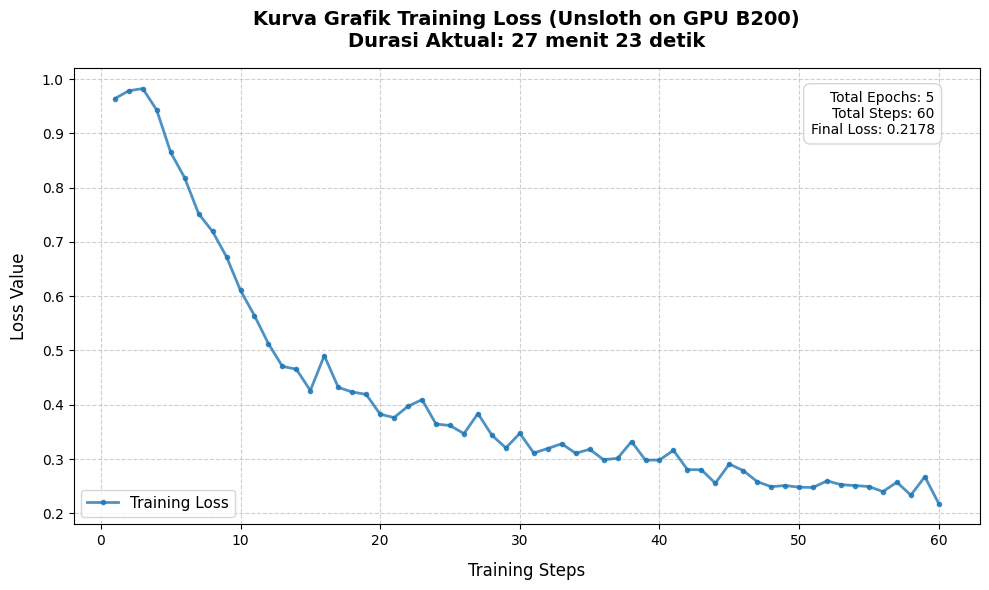

In [ ]:
# import matplotlib.pyplot as plt

# # 1. Ambil log history untuk visualisasi Training Loss
# log_history = trainer.state.log_history

# # Saring data untuk mengambil langkah yang berisi 'loss' (bukan evaluasi)
# steps = [log.get("step") for log in log_history if "loss" in log]
# losses = [log.get("loss") for log in log_history if "loss" in log]

# # 2. Ambil waktu aktual dari trainer_stats
# metrics = trainer_stats.metrics
# total_seconds = metrics.get("train_runtime", 0)

# # Konversi detik ke jam, menit, dan detik
# hours = int(total_seconds // 3600)
# minutes = int((total_seconds % 3600) // 60)
# seconds = int(total_seconds % 60)

# # Format teks durasi waktu aktual
# waktu_aktual = f"{hours} jam {minutes} menit {seconds} detik" if hours > 0 else f"{minutes} menit {seconds} detik"

# print(f"\n>>> [INFO] Grafik Training Loss sedang dibuat...")
# print(f">>> [INFO] Waktu Aktual Training: {waktu_aktual}")

# # 3. Membuat Grafik Visualisasi Training Loss
# plt.figure(figsize=(10, 6))

# # Plot kurva loss (Warna biru tua khas visualisasi profesional)
# plt.plot(steps, losses, label="Training Loss", color="#1f77b4", linewidth=2, marker='o', markersize=3, alpha=0.8)

# # Kostumisasi tampilan grafik
# plt.title(f"Kurva Grafik Training Loss (Unsloth on GPU B200)\nDurasi Aktual: {waktu_aktual}", fontsize=14, fontweight='bold', pad=15)
# plt.xlabel("Training Steps", fontsize=12, labelpad=10)
# plt.ylabel("Loss Value", fontsize=12, labelpad=10)
# plt.grid(True, linestyle="--", alpha=0.6)
# plt.legend(fontsize=11)

# # Tambahkan catatan teks info di dalam grafik (opsional)
# info_text = f"Total Epochs: {NUM_EPOCHS}\nTotal Steps: {max(steps) if steps else MAX_STEPS}\nFinal Loss: {losses[-1]:.4f}"
# plt.gca().text(0.95, 0.95, info_text, transform=plt.gca().transAxes, fontsize=10,
#             verticalalignment='top', horizontalalignment='right',
#             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='#ccc'))

# plt.tight_layout()

# # 4. Simpan dan Tampilkan Gambar
# plt.savefig("outputs_lora/training_loss_curve_v3.png", dpi=300)
# print(">>> [SUKSES] Grafik berhasil disimpan di 'outputs_lora/training_loss_curve.png'")
# plt.show()


## 5. Menyimpan LoRA Adapter
Setelah puas dengan hasil *fine-tuning*, kita bisa menyimpan model atau adapter LoRA-nya saja.

In [ ]:
model.save_pretrained("lora_adapter_raft_perdes_v3")
tokenizer.save_pretrained("model_merged_raft_perdes_v3")

Unsloth: Restored added_tokens_decoder metadata in model_merged_raft_perdes_v2/tokenizer_config.json.


('model_merged_raft_perdes_v2/tokenizer_config.json',
 'model_merged_raft_perdes_v2/chat_template.jinja',
 'model_merged_raft_perdes_v2/tokenizer.json')

In [ ]:
# Ini cara yang BENAR untuk menyimpan LoRA Adapter beserta Tokenizer-nya
model.save_pretrained("lora_adapter_raft_perdes_v4")
tokenizer.save_pretrained("lora_adapter_raft_perdes_v4")


Unsloth: Restored added_tokens_decoder metadata in lora_adapter_raft_perdes_v4/tokenizer_config.json.


('lora_adapter_raft_perdes_v4/tokenizer_config.json',
 'lora_adapter_raft_perdes_v4/chat_template.jinja',
 'lora_adapter_raft_perdes_v4/tokenizer.json')

In [ ]:
# Ini cara yang BENAR untuk menyimpan Merged Model (digabung penuh)
model.save_pretrained_merged("model_merged_raft_perdes_v3", tokenizer, save_method="merged_16bit")


Detected local model directory: /workspace/model/Meta-Llama-3.1-8B-Instruct


RuntimeError: Failed saving - no disk space left!